# 1.4 Data Manipulation — Concepts & Examples

Data rarely arrives clean. These five techniques are applied on **every** real ML project before a model can be trained.

---

## 📋 Topics Covered

| # | Topic | Key Concepts |
|---|-------|-------------|
| 1 | **Missing Value Handling** | `isnull()` · count & % missing · drop columns / rows · fill with mean / median / mode · forward fill / backward fill / interpolation · missing value heatmap |
| 2 | **Encoding Categorical Variables** | Label encoding (ordinal, manual map) · one-hot encoding `pd.get_dummies()` · ordinal encoding with custom order · `drop_first` (dummy variable trap) · `pd.concat(axis=1)` |
| 3 | **Feature Scaling** | `MinMaxScaler` → [0,1] · `StandardScaler` → mean=0 std=1 · `RobustScaler` → median/IQR (outlier-resistant) · `fit_transform()` · when to use each scaler |
| 4 | **Date & Time Handling** | `pd.to_datetime()` · `.dt` accessor (year, month, day, weekday, quarter, week) · date arithmetic with `Timestamp` → `timedelta` · `.dt.days` / divide by 365.25 · `resample('W')` / `resample('M')` |
| 5 | **String Processing** | `.str.strip()` / `.str.title()` / `.str.split()` · `.str.extract(regex)` with capture groups · `.str.replace(regex)` · `.str.contains()` for filtering · method chaining |

---

### Quick Reference — Missing Value Strategies

| Column type | Missing % | Strategy |
|-------------|-----------|----------|
| Numeric | Any | Median (outliers) or Mean (clean) |
| Categorical | Any | Mode (most frequent value) |
| Time-series | Any | `ffill()`, `bfill()`, or `interpolate()` |
| Any | > 50–60% | Drop the column |

> **Always create a `_was_missing` indicator column BEFORE filling** — the fact that a value was missing can itself be a useful ML feature.

### Quick Reference — Which Scaler to Use?

| Situation | Best scaler |
|-----------|------------|
| No outliers, need [0,1] range | `MinMaxScaler` |
| No outliers, most algorithms | `StandardScaler` |
| Outliers present | `RobustScaler` |
| Tree-based models (RF, XGBoost) | No scaling needed |

### Quick Reference — Encoding Decision

| Category type | Example | Encoding |
|---------------|---------|----------|
| Ordinal (has natural order) | Small < Medium < Large | Label / Ordinal (manual map) |
| Nominal (no order) | Red, Blue, Green | One-Hot (`get_dummies`) |
| High cardinality nominal | City (500+ values) | Target encoding |

### Quick Reference — `.dt` Accessor Properties

| Property | Returns |
|----------|---------|
| `.dt.year` / `.dt.month` / `.dt.day` | Integer components |
| `.dt.day_name()` | "Monday", "Tuesday", … |
| `.dt.month_name()` | "January", "February", … |
| `.dt.quarter` | 1, 2, 3, 4 |
| `.dt.dayofweek` | 0=Monday … 6=Sunday |
| `.dt.is_month_end` | True/False |

### Quick Reference — Useful Regex Patterns for Strings

| Pattern | Matches |
|---------|---------|
| `r'\d+'` | One or more digits |
| `r'[^\d]'` | Any non-digit character |
| `r'^([^@]+)@'` | Username before `@` in email |
| `r'@([^.]+)\.'` | Domain between `@` and `.` |
| `r'(\d)/5'` | Rating like `4/5` |

---

> **How to use this notebook:** Read the explanation cell above each code block first, then run the cell and observe the output.

**What this cell does:** Imports all required libraries. `sklearn.preprocessing` provides ready-made scalers and encoders used later in the notebook. `%matplotlib inline` ensures plots display inside the notebook.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler, RobustScaler

%matplotlib inline
print("Libraries loaded!")

Libraries loaded!


---
## 1. Missing Value Handling

Real datasets almost always have missing values (shown as `NaN` in Pandas).

### Detection
- `df.isnull()` — True where NaN
- `df.isnull().sum()` — count per column
- `df.isnull().mean() * 100` — percentage per column

### Strategies
| Strategy | When to use |
|----------|-------------|
| **Drop rows** | Few missing, random pattern |
| **Drop columns** | >50-60% missing |
| **Fill with mean/median** | Numeric, no extreme skew |
| **Fill with median** | Numeric with outliers |
| **Fill with mode** | Categorical |
| **Forward/backward fill** | Time-series data |
| **Predict** | Important feature, complex pattern |

An outlier is a data point that is significantly different from the rest of the data.
Ages in a dataset: [22, 25, 27, 24, 26, 23, 95]

→ 95 is an outlier. Everyone else is in their 20s.

In [ ]:
# How to detect outliers in a dataset?
# 1. Using Z-score
# 2. Using IQR (Interquartile Range)
# 3. Using Box Plot
# 4. Using Scatter Plot
# 5. Using Density Plot
# 6. Using Mahalanobis Distance
# 7. Using Isolation Forest
# 8. Using Local Outlier Factor (LOF)
# 9. Using DBSCAN (Density-Based Spatial Clustering of Applications with Noise)
# 10. Using Autoencoders (Neural Networks)

In [ ]:
# Q1 = df['income'].quantile(0.25)
# Q3 = df['income'].quantile(0.75)
# IQR = Q3 - Q1

# lower = Q1 - 1.5 * IQR
# upper = Q3 + 1.5 * IQR

# outliers = df[(df['income'] < lower) | (df['income'] > upper)]


In [ ]:
# Method 2 — Z-score Rule

# from scipy import stats
# z_scores = stats.zscore(df['income'])
# outliers = df[abs(z_scores) > 3]   # more than 3 std deviations from mean


In [ ]:
# Method 3 — Boxplot (visual)


# import seaborn as sns
# sns.boxplot(x=df['income'])

### Why Missing Value Handling?

**Why it happens:** Data is collected from multiple sources — forms people skip, sensors that fail, database joins that leave gaps. Missing values appear as `NaN` in Pandas.

**Why it matters for ML:** Most ML algorithms crash or silently produce wrong results when given `NaN`. Scikit-learn will throw a `ValueError` if your training data has any missing values — the pipeline breaks before the model even runs.

**Why each strategy exists:**
- **Drop column** — If >50–60% of a column is missing, even the best imputation is mostly made-up data. Keeping it adds noise, not signal.
- **Fill with median** — Median is the middle value, so it is not pulled by outliers. Preferred for numeric columns in real data (income, age).
- **Fill with mean** — Use only when the distribution is clean and symmetric. An extreme outlier in income would make the mean misleading.
- **Fill with mode** — For categorical columns there is no mean/median, so you use the most frequent value.
- **ffill / bfill / interpolate** — For time-series data, rows have a time order. It makes more sense to fill a gap using the previous or next known value than a global average.

**Pro tip — create a `_was_missing` indicator column BEFORE filling.** The fact that a value was missing is information itself. A model can learn "customers who didn't fill in their income field churn more" — but only if you preserve that signal.

```python
df['age_was_missing'] = df['age'].isnull().astype(int)  # 1 = was missing
df['age'] = df['age'].fillna(df['age'].median())
```

**What this cell does:** Builds a small DataFrame with **intentional missing values** (`np.nan`) planted in specific positions to simulate a messy real-world dataset.
- `df.isnull().sum()` counts how many NaN values are in each column
- `df.isnull().mean() * 100` converts that to a percentage — multiply by 100 because `.mean()` gives a proportion (0.0 to 1.0)
- `junk_col` is entirely NaN — this represents a column that should be dropped entirely

In [2]:
# Build a dataset with intentional missing values
np.random.seed(42)
df = pd.DataFrame({
    'age'     : [25, np.nan, 35, 28, np.nan, 45, 32, np.nan, 29, 38],
    'income'  : [50000, 60000, np.nan, 45000, 70000, np.nan, 55000, 80000, np.nan, 65000],
    'gender'  : ['M', 'F', np.nan, 'M', 'F', 'M', np.nan, 'F', 'M', 'F'],
    'score'   : [85, 90, 78, np.nan, 92, 88, np.nan, 95, 70, np.nan],
    'junk_col': [np.nan]*10   # entirely missing
})
print("Shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())
print("\nMissing %:")
print((df.isnull().mean() * 100).round(1))

Shape: (10, 5)

Missing values:
age          3
income       3
gender       2
score        3
junk_col    10
dtype: int64

Missing %:
age          30.0
income       30.0
gender       20.0
score        30.0
junk_col    100.0
dtype: float64


**What this cell does:** Applies appropriate imputation strategies for each column:
- `drop(columns=['junk_col'])` — removes the 100% missing column first. No imputation strategy can help a completely empty column.
- `fillna(df['age'].median())` — replaces NaN in `age` with the **median** (middle value). Median is preferred over mean for numeric columns because it is not affected by extreme outliers.
- `fillna(df['income'].mean())` — uses mean for income (showing the alternative).
- `fillna(df['gender'].mode()[0])` — for categorical data, use the **mode** (most frequent value). `.mode()` returns a Series so `[0]` gets the first (most common) value.
- The final `.sum().sum()` counts total remaining NaNs — it should be 0.

In [3]:
# Drop fully-missing column
df = df.drop(columns=['junk_col'])

# Fill numeric: age -> median, income -> mean, score -> median
df['age']    = df['age'].fillna(df['age'].median())
df['income'] = df['income'].fillna(df['income'].mean())
df['score']  = df['score'].fillna(df['score'].median())

# Fill categorical: gender -> mode
df['gender'] = df['gender'].fillna(df['gender'].mode()[0])

print("After filling:\n", df)
print("\nRemaining nulls:", df.isnull().sum().sum())

After filling:
     age        income gender  score
0  25.0  50000.000000      M   85.0
1  32.0  60000.000000      F   90.0
2  35.0  60714.285714      F   78.0
3  28.0  45000.000000      M   88.0
4  32.0  70000.000000      F   92.0
5  45.0  60714.285714      M   88.0
6  32.0  55000.000000      F   88.0
7  32.0  80000.000000      F   95.0
8  29.0  60714.285714      M   70.0
9  38.0  65000.000000      F   88.0

Remaining nulls: 0


**What this cell does:** Demonstrates three **time-series imputation** methods on a Series with gaps:
- `ffill()` (**forward fill**) — copies the last known value forward to fill subsequent NaNs. E.g., `[10, NaN, NaN, 40]` becomes `[10, 10, 10, 40]`.
- `bfill()` (**backward fill**) — fills NaNs from the next known value backward.
- `interpolate()` — fills NaNs by **linear interpolation** (calculates in-between values on a straight line). E.g., gap between 10 and 40 with 2 missing → `[10, 20, 30, 40]`. This is usually the most accurate approach for time-series.

In [4]:
# Forward fill (time-series pattern)
ts = pd.Series([10, np.nan, np.nan, 40, np.nan, 60])
print("Original     :", ts.tolist())
print("Forward fill :", ts.ffill().tolist())
print("Backward fill:", ts.bfill().tolist())
print("Interpolated :", ts.interpolate().tolist())

Original     : [10.0, nan, nan, 40.0, nan, 60.0]
Forward fill : [10.0, 10.0, 10.0, 40.0, 40.0, 60.0]
Backward fill: [10.0, 40.0, 40.0, 40.0, 60.0, 60.0]
Interpolated : [10.0, 20.0, 30.0, 40.0, 50.0, 60.0]


**What this cell does:** Creates a visual heatmap of where missing values are in a small sample DataFrame. `sns.heatmap(df.isnull(), ...)` maps the boolean True/False matrix (True = missing) to red/white colours. At a glance you can see the pattern — are missing values concentrated in certain rows (indicating a systematic problem) or scattered randomly? `cbar=False` removes the colour scale bar since we only have two values.

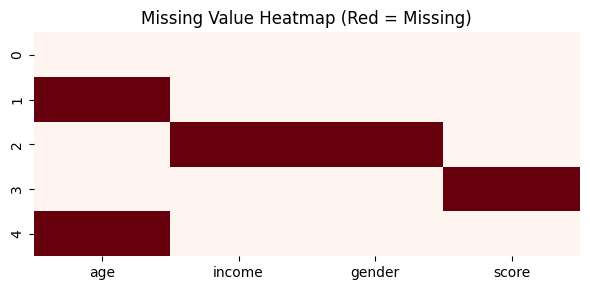

In [5]:
# Visualise missing data pattern (before filling)
df_raw = pd.DataFrame({
    'age'   : [25, np.nan, 35, 28, np.nan],
    'income': [50000, 60000, np.nan, 45000, 70000],
    'gender': ['M', 'F', np.nan, 'M', 'F'],
    'score' : [85, 90, 78, np.nan, 92]
})
fig, ax = plt.subplots(figsize=(6, 3))
sns.heatmap(df_raw.isnull(), cbar=False, cmap='Reds', ax=ax)
ax.set_title('Missing Value Heatmap (Red = Missing)')
plt.tight_layout()
plt.show()

In [ ]:
#          age    income   gender   score
# Row 0  [ white  white    white    white ]   ← complete row, no missing
# Row 1  [ RED    white    white    white ]   ← age is missing
# Row 2  [ white  RED      RED      white ]   ← income & gender missing
# Row 3  [ white  white    white    RED   ]   ← score missing


---
## 2. Encoding Categorical Variables

ML algorithms work with numbers. Categorical text must be encoded.

| Method | When to use | Example |
|--------|-------------|--------|
| **Label Encoding** | Ordinal categories (order matters) | Low=0, Mid=1, High=2 |
| **One-Hot Encoding** | Nominal categories (no order) | Red→[1,0,0], Blue→[0,1,0] |
| **Ordinal Encoding** | Custom ordering | Bad<OK<Good<Excellent |
| **Target Encoding** | High-cardinality, regression | Replace with mean target |

> **Warning:** Never use Label Encoding on nominal data — it implies a false ordering.

### Why Encoding Categorical Variables?

**Why it is necessary:** ML algorithms are mathematical functions — they perform multiplications, additions, dot products. You cannot multiply `"Red"` by a weight. Every text category must become a number before any model can process it.

**Why different methods exist:**

**Label / Ordinal Encoding** — assigns an integer to each category. Only correct when the category has a real order:
- ✅ `Small=0, Medium=1, Large=2` — the order is real, the gap between sizes is meaningful
- ❌ `Red=0, Blue=1, Green=2` — a model would learn Green > Blue > Red, which is mathematically nonsense

**One-Hot Encoding** — creates a separate 0/1 column per category. Each row has exactly one `1` and the rest `0`. No false ordering is introduced. Use this for any nominal (no-order) category like color, city, job title.

**The Dummy Variable Trap** — with 3 colors you only need 2 columns. If `Blue=0` AND `Green=0`, it must be Red — the third column contains no new information and causes multicollinearity in linear models. `drop_first=True` removes the redundant column.

**High-cardinality columns** (e.g., City with 500 values) — One-hot would create 500 new columns, most nearly empty. Use Target Encoding instead (replace each city with its mean outcome value).

**What this cell does:** Creates a sample DataFrame with three categorical columns to practice different encoding strategies on. Notice the three different types:
- `size` — **ordinal** (Small < Medium < Large — order matters)
- `color` — **nominal** (Red, Blue, Green have no natural order)
- `quality` — **ordinal** with a custom scale (Bad < OK < Good < Excellent)

In [6]:
df_enc = pd.DataFrame({
    'size'    : ['Small','Medium','Large','Small','Large','Medium'],
    'color'   : ['Red','Blue','Green','Blue','Red','Green'],
    'quality' : ['Good','Bad','Excellent','OK','Excellent','Good'],
    'price'   : [10, 20, 30, 12, 28, 22]
})
print(df_enc)

     size  color    quality  price
0   Small    Red       Good     10
1  Medium   Blue        Bad     20
2   Large  Green  Excellent     30
3   Small   Blue         OK     12
4   Large    Red  Excellent     28
5  Medium  Green       Good     22


**What this cell does:** Applies **label encoding** to the ordinal `size` column using a manually defined mapping dictionary. `df['size'].map(size_map)` looks up each value in the dict and replaces it with the corresponding integer. Using a manual dict is better than sklearn's `LabelEncoder` here because we control the exact order: Small=0 < Medium=1 < Large=2. `LabelEncoder` assigns alphabetical order (Large=0, Medium=1, Small=2) which would be wrong.

In [7]:
# ---- Label Encoding (ordinal: Small < Medium < Large) ----
size_map = {'Small': 0, 'Medium': 1, 'Large': 2}
df_enc['size_encoded'] = df_enc['size'].map(size_map)
print("Label encoded size:\n", df_enc[['size','size_encoded']])

Label encoded size:
      size  size_encoded
0   Small             0
1  Medium             1
2   Large             2
3   Small             0
4   Large             2
5  Medium             1


**What this cell does:** Applies **one-hot encoding** to the nominal `color` column using `pd.get_dummies()`. This creates one new binary column per unique category:
- `color_Blue` — 1 if the row is Blue, else 0
- `color_Green` — 1 if Green, else 0
- `color_Red` — 1 if Red, else 0

`pd.concat([df_enc, ohe], axis=1)` appends these new columns to the right of the original DataFrame. `axis=1` means "join column-wise" (side by side), as opposed to `axis=0` which would stack rows.

In [8]:
# ---- One-Hot Encoding (nominal: color has no order) ----
ohe = pd.get_dummies(df_enc['color'], prefix='color')
df_ohe = pd.concat([df_enc, ohe], axis=1)
print("One-Hot Encoded color:\n", df_ohe[['color','color_Blue','color_Green','color_Red']])

One-Hot Encoded color:
    color  color_Blue  color_Green  color_Red
0    Red           0            0          1
1   Blue           1            0          0
2  Green           0            1          0
3   Blue           1            0          0
4    Red           0            0          1
5  Green           0            1          0


**What this cell does:** Applies **ordinal encoding** to `quality` using a custom dictionary that reflects the real order of the values (Bad=0, OK=1, Good=2, Excellent=3). This is identical in technique to the size encoding but explicitly shows that ordinal encoding preserves meaningful rank information — a model can learn that `Excellent=3` is better than `Good=2`.

In [9]:
# ---- Ordinal Encoding with custom order ----
quality_order = {'Bad': 0, 'OK': 1, 'Good': 2, 'Excellent': 3}
df_enc['quality_encoded'] = df_enc['quality'].map(quality_order)
print("Quality encoded:\n", df_enc[['quality','quality_encoded']])

Quality encoded:
      quality  quality_encoded
0       Good                2
1        Bad                0
2  Excellent                3
3         OK                1
4  Excellent                3
5       Good                2


**What this cell does:** Demonstrates the **dummy variable trap** and why `drop_first=True` matters. With 3 color categories (Red, Blue, Green), you only need 2 columns to represent them fully — if `Blue=0` and `Green=0`, it must be `Red`. The third column is **perfectly predictable** from the other two, which causes multicollinearity (redundant information). `drop_first=True` drops `color_Blue` and keeps only `color_Green` and `color_Red`. This matters for linear models like logistic regression; tree-based models are not affected.

In [10]:
# ---- drop_first to avoid multicollinearity (dummy variable trap) ----
# With 3 colors: Red, Blue, Green
# If Blue=0 and Green=0 -> must be Red. So we only need 2 columns.
ohe_nodrop = pd.get_dummies(df_enc['color'], prefix='color')
ohe_drop   = pd.get_dummies(df_enc['color'], prefix='color', drop_first=True)
print("Without drop_first (3 cols):\n", ohe_nodrop.head(3))
print("With drop_first (2 cols):\n",    ohe_drop.head(3))

Without drop_first (3 cols):
    color_Blue  color_Green  color_Red
0           0            0          1
1           1            0          0
2           0            1          0
With drop_first (2 cols):
    color_Green  color_Red
0            0          1
1            0          0
2            1          0


---
## 3. Feature Scaling

Many ML algorithms (KNN, SVM, neural networks, gradient descent) are sensitive to feature magnitude. Scaling brings features to comparable ranges.

| Method | Formula | Range | Best for |
|--------|---------|-------|----------|
| **Min-Max** | `(x - min)/(max - min)` | [0, 1] | When you need bounded range |
| **Standard (Z-score)** | `(x - mean)/std` | ~[-3, 3] | Most ML algorithms |
| **Robust** | `(x - median)/IQR` | Varies | Data with outliers |

### Why Feature Scaling?

**Why it matters:** Different features live on wildly different numeric scales:
- `age`: 20–45
- `income`: 30,000–200,000
- `score`: 60–90

When features differ in magnitude by thousands, algorithms that rely on distances or gradients are misled:

- **KNN** — distance between two rows is dominated by `income` (large numbers). `age` and `score` become invisible to the model.
- **Neural Networks / Gradient Descent** — the loss landscape becomes elongated. Optimization is slow and unstable. Scaling makes it converge much faster.
- **SVM** — the kernel uses distances. A feature with huge values dominates the decision boundary.
- **Logistic / Linear Regression** — coefficients become incomparable. Scaling makes them interpretable again.

**Why tree models do NOT need scaling:** Random Forest, XGBoost, Decision Trees use splits (`if income > 75000`). A split point scales with the data automatically — the split threshold just changes, the model behavior does not.

**Why three different scalers:**
- `MinMaxScaler` — simple, clean, bounded [0,1]. Falls apart when one row has an extreme outlier — that outlier becomes 1.0 and everything else gets squished to the bottom.
- `StandardScaler` — removes the mean and divides by std. Works well for most algorithms. Still affected by outliers because std is calculated from all values.
- `RobustScaler` — uses median and IQR (the middle 50% of the data). Outliers are in the outer 25%, so they barely affect the scaling. Best choice when your data has outliers.

**Critical rule — fit on train data only:**
```python
scaler.fit(X_train)                          # learn statistics from training set
X_train_scaled = scaler.transform(X_train)
X_test_scaled  = scaler.transform(X_test)   # apply the SAME statistics to test
```
Never fit on test data. The test set represents future/unseen data — using its statistics to scale would leak future information into training.

In [ ]:
# MinMax Scaler

# Original income: [30000, 50000, 80000, 100000]

# min = 30000
# max = 100000

# 30000  → (30000 - 30000) / (100000 - 30000) = 0/70000  = 0.00
# 50000  → (50000 - 30000) / (100000 - 30000) = 20000/70000 = 0.29
# 80000  → (80000 - 30000) / (100000 - 30000) = 50000/70000 = 0.71
# 100000 → (100000 - 30000) / (100000 - 30000) = 70000/70000 = 1.00

# The minimum always becomes 0, the maximum always becomes 1, everything else falls in between.

**What this cell does:** Creates a dataset with three features of very different scales — `age` (20s-40s), `income` (30k-200k with one outlier), `score` (60-90). Then applies all three scalers:
- `scaler.fit_transform(data)` — `fit` computes the statistics (min, max, mean, std etc.) from the data, then `transform` applies the scaling. Returns a NumPy array which is wrapped back into a DataFrame.
- The last lines compare how each scaler handles `income` — the column with an extreme outlier (200k). Notice how differently the values look after each scaler.

In [11]:
data = pd.DataFrame({
    'age'   : [25, 30, 35, 28, 45, 32, 29, 38],
    'income': [30000, 50000, 80000, 40000, 200000, 60000, 35000, 90000],  # outlier: 200k
    'score' : [60, 70, 80, 65, 90, 75, 62, 85]
})

# Min-Max Scaler
mm = MinMaxScaler()
data_mm = pd.DataFrame(mm.fit_transform(data), columns=data.columns)

# Standard Scaler
ss = StandardScaler()
data_ss = pd.DataFrame(ss.fit_transform(data), columns=data.columns)

# Robust Scaler
rs = RobustScaler()
data_rs = pd.DataFrame(rs.fit_transform(data), columns=data.columns)

print("Original Income:\n", data['income'].values)
print("Min-Max Income: ", data_mm['income'].round(3).values)
print("Standard Income:", data_ss['income'].round(3).values)
print("Robust Income:  ", data_rs['income'].round(3).values)

Original Income:
 [ 30000  50000  80000  40000 200000  60000  35000  90000]
Min-Max Income:  [0.    0.118 0.294 0.059 1.    0.176 0.029 0.353]
Standard Income: [-0.831 -0.446  0.132 -0.638  2.445 -0.253 -0.735  0.325]
Robust Income:   [-0.571 -0.114  0.571 -0.343  3.314  0.114 -0.457  0.8  ]


**What this cell does:** Creates a 1×4 grid of boxplots to visually compare the effect of each scaling method on the data. Each subplot shows the same three features (`age`, `income`, `score`) after a different transformation. This makes it immediately obvious:
- Original: `income` dominates completely (scale 0–200k vs 20–90)
- Min-Max: all values 0–1, but outlier squishes everything else to bottom
- Standard: centred at 0, but outlier becomes extreme (~10 standard deviations)
- Robust: outlier handled gracefully, normal values spread out evenly

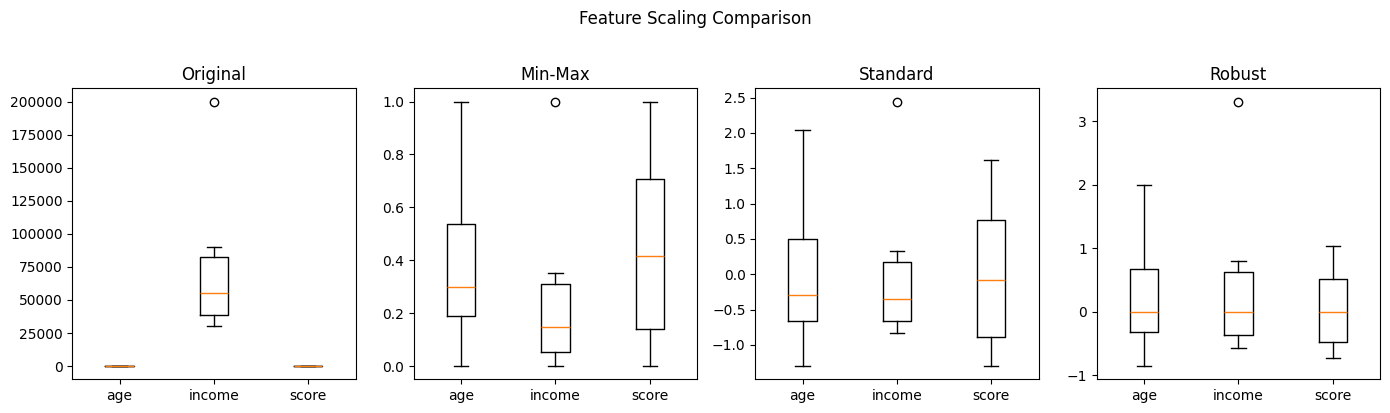

In [12]:
# Visualise the effect of each scaler
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, (title, d) in zip(axes, [
    ('Original',     data),
    ('Min-Max',      data_mm),
    ('Standard',     data_ss),
    ('Robust',       data_rs)
]):
    ax.boxplot([d['age'], d['income'], d['score']], labels=['age','income','score'])
    ax.set_title(title)
plt.suptitle('Feature Scaling Comparison', y=1.02)
plt.tight_layout()
plt.show()

---
## 4. Date & Time Handling

Pandas uses `datetime64` for timestamps. Key operations:
- Convert strings → datetime with `pd.to_datetime()`
- Extract components via the `.dt` accessor
- Arithmetic: subtract two dates, add offsets
- Resample time-series data

### Why Date & Time Handling?

**Why raw dates are useless to a model:** A date string like `"2024-01-15"` is just text — a model cannot do math with it. Even if stored as a number (Unix timestamp), the raw number carries no useful pattern. What the model actually needs are the *components* of the date.

**Why date features are powerful:**
- **Day of week** → captures weekday vs weekend behavior (retail sales spike on Saturday)
- **Month / Quarter** → captures seasonality (heating bills spike in winter)
- **Week number** → captures weekly cycles
- **Days since event** → captures recency (how long since a customer last purchased)
- **Is month end / quarter end** → captures business cycle effects

These features allow the model to learn human patterns tied to calendar time.

**Why `pd.to_datetime()` is essential:** Date strings come in dozens of formats (`"2024-01-15"`, `"15/01/2024"`, `"January 15 2024"`). `pd.to_datetime()` handles all of them and converts to a single consistent `datetime64` type, unlocking the `.dt` accessor.

**Why divide by 365.25 (not 365) for years:**
Every 4 years there is a leap year with 366 days. Dividing by 365 would accumulate a small error over time. 365.25 is the average days per year accounting for leap years — important for accurate tenure calculations.

**Why resampling?** Raw time-series data is often too granular (daily transactions). Resampling lets you:
- Reduce noise by aggregating to weekly/monthly
- Align data from different frequencies before joining
- Spot longer-term trends hidden in day-to-day fluctuations

**What this cell does:** Shows that `pd.to_datetime()` can parse many different date string formats automatically — dashes, slashes, month names, etc. It converts them all to Python's `datetime64` type. The `dayfirst=False` parameter tells Pandas to treat ambiguous formats like `05-06-2024` as MM-DD-YYYY (May 6) rather than DD-MM-YYYY (June 5). Always set this explicitly to avoid silent bugs.

In [13]:
# ---- Parse various date formats ----
dates = ['2024-01-15', '2024/03/22', 'April 5 2024', '05-06-2024']
parsed = pd.to_datetime(dates, dayfirst=False)
for orig, p in zip(dates, parsed):
    print(f"{orig!r:20} -> {p.date()}")

'2024-01-15'         -> 2024-01-15
'2024/03/22'         -> 2024-03-22
'April 5 2024'       -> 2024-04-05
'05-06-2024'         -> 2024-05-06


**What this cell does:** Demonstrates the **`.dt` accessor** — once a column is `datetime64` type, `.dt` unlocks all date/time properties:
- `.dt.year`, `.dt.month`, `.dt.day` — numeric components
- `.dt.day_name()` — day of week as a string ("Monday", "Tuesday", etc.)
- `.dt.quarter` — 1, 2, 3, or 4
- `.dt.isocalendar().week` — ISO week number (1–53)

These are used to create date-based features for ML (e.g., "is it weekend?", "which quarter?").

In [14]:
# ---- .dt accessor: extract components ----
df_dates = pd.DataFrame({
    'event'     : ['Launch','Review','Deploy','Meeting','Release'],
    'date_str'  : ['2024-01-15','2024-03-22','2024-07-04','2024-11-28','2024-12-25']
})
df_dates['date']      = pd.to_datetime(df_dates['date_str'])
df_dates['year']      = df_dates['date'].dt.year
df_dates['month']     = df_dates['date'].dt.month
df_dates['day']       = df_dates['date'].dt.day
df_dates['weekday']   = df_dates['date'].dt.day_name()
df_dates['quarter']   = df_dates['date'].dt.quarter
df_dates['week_num']  = df_dates['date'].dt.isocalendar().week
print(df_dates)

     event    date_str       date  year  month  day    weekday  quarter  \
0   Launch  2024-01-15 2024-01-15  2024      1   15     Monday        1   
1   Review  2024-03-22 2024-03-22  2024      3   22     Friday        1   
2   Deploy  2024-07-04 2024-07-04  2024      7    4   Thursday        3   
3  Meeting  2024-11-28 2024-11-28  2024     11   28   Thursday        4   
4  Release  2024-12-25 2024-12-25  2024     12   25  Wednesday        4   

   week_num  
0         3  
1        12  
2        27  
3        48  
4        52  


---

**What this cell does:** Shows **date arithmetic** — subtracting two datetime columns. `today - hire_dates` produces a Series of `timedelta` objects (durations). `.dt.days` extracts the integer number of days from the timedelta. Dividing by 365.25 (not 365) accounts for leap years and gives a more accurate year count. This is how you compute tenure, age, or days since an event.

In [16]:
# ---- Date arithmetic ----
from datetime import date

hire_dates = pd.to_datetime(['2020-03-15', '2018-07-01', '2022-11-20', '2019-01-10'])
today      = pd.Timestamp('2024-04-16')

tenure_days = (today - hire_dates).days
tenure_yrs  = tenure_days / 365.25

for h, t in zip(hire_dates, tenure_yrs):
    print(f"Hired {h.date()} -> {t:.1f} years tenure")

Hired 2020-03-15 -> 4.1 years tenure
Hired 2018-07-01 -> 5.8 years tenure
Hired 2022-11-20 -> 1.4 years tenure
Hired 2019-01-10 -> 5.3 years tenure


In [ ]:
# Hire Date    Today        Days Apart   ÷ 365.25   Result
# ──────────   ──────────   ──────────   ────────   ──────
# 2020-03-15   2024-04-16     1492        ÷ 365.25   4.1 yrs
# 2018-07-01   2024-04-16     2116        ÷ 365.25   5.8 yrs
# 2022-11-20   2024-04-16      513        ÷ 365.25   1.4 yrs
# 2019-01-10   2024-04-16     1922        ÷ 365.25   5.3 yrs


---

**What this cell does:** Shows **resampling** — aggregating time-series data to a coarser time period.
- `pd.date_range(...)` creates a sequence of 90 daily timestamps (the index for our series)
- `ts.resample('W').sum()` — groups data by **week** and sums each group
- `ts.resample('ME').mean()` — groups by **month end** and takes the mean

This is the time-series equivalent of GroupBy — instead of grouping by a category column, you group by time windows. The plot shows how daily noise becomes smoother as you zoom out to weekly, then monthly.

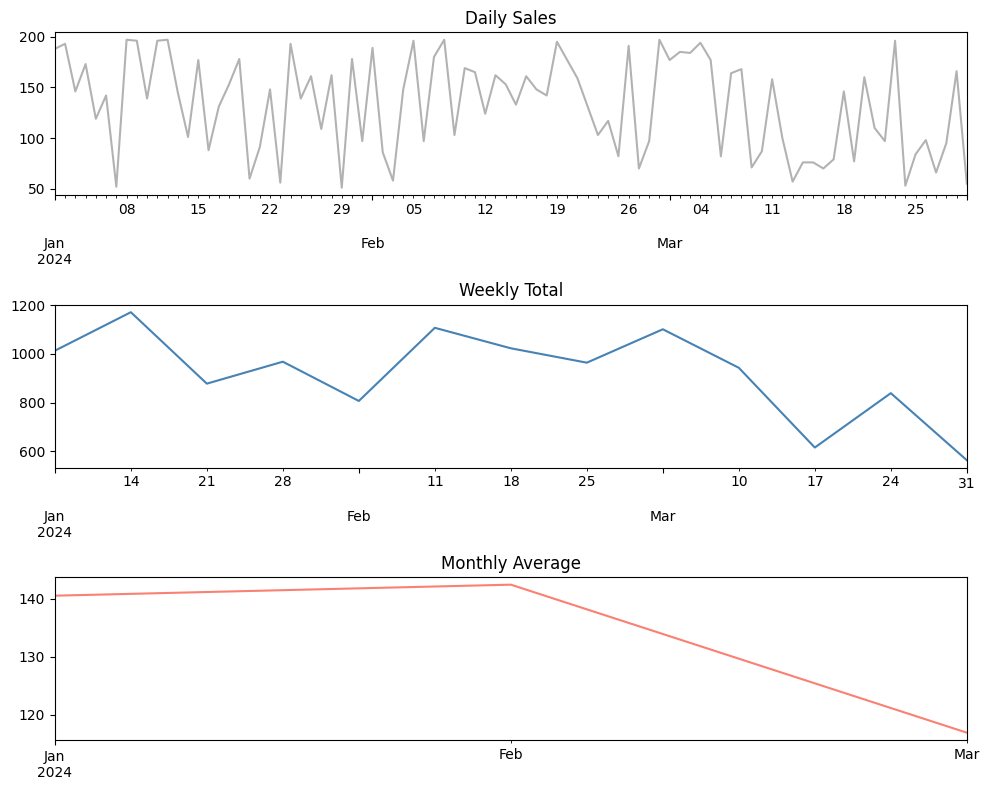

In [19]:
# ---- Resampling a time-series ----
idx     = pd.date_range('2024-01-01', periods=90, freq='D')
ts      = pd.Series(np.random.randint(50, 200, 90), index=idx, name='daily_sales')

weekly  = ts.resample('W').sum()
monthly = ts.resample('M').mean()

fig, axes = plt.subplots(3, 1, figsize=(10, 8))
ts.plot(ax=axes[0],      title='Daily Sales',   color='gray', alpha=0.6)
weekly.plot(ax=axes[1],  title='Weekly Total',  color='steelblue')
monthly.plot(ax=axes[2], title='Monthly Average',color='salmon')
plt.tight_layout()
plt.show()

---
## 5. String Processing

Pandas `.str` accessor mirrors Python string methods but works **vectorised** on a Series.

Key methods: `.str.lower()`, `.str.strip()`, `.str.replace()`, `.str.split()`, `.str.contains()`, `.str.extract()`, `.str.len()`

### Why String Processing?

**Why strings need cleaning before ML:** Text columns from real systems are inconsistent — collected from forms, web scraping, legacy databases, or manual entry. The same value appears as `"  alice smith "`, `"Alice Smith"`, `"ALICE SMITH"` — a model treats all three as completely different categories.

**Why vectorised `.str` methods instead of loops:**
```python
# Slow — processes one row at a time
for i, row in df.iterrows():
    df.at[i, 'name'] = row['name'].strip().title()

# Fast — operates on the entire column at once
df['name'] = df['name'].str.strip().str.title()
```
Pandas `.str` methods are implemented in C under the hood and operate on the entire column simultaneously — orders of magnitude faster on large datasets.

**Why regex is important for string processing:**
- Regex lets you describe a *pattern* rather than a specific string
- `r'[^\d]'` means "any character that is NOT a digit" — one pattern cleans all phone formats at once
- Without regex you would need separate `.replace()` calls for every possible format

**Why string features matter for ML:**
- Extracting a rating from free text (`"Great service! 5 stars"` → `5`) turns unstructured text into a numeric feature
- Extracting email domain (`gmail`, `yahoo`, `outlook`) can be a predictive feature (e.g., corporate vs personal users)
- Normalizing inconsistent values ensures the model sees `"New York"` and `"new york"` as the same category, not two different ones

**What this cell does:** Sets up a messy DataFrame that simulates common real-world data quality problems:
- Names have extra spaces, inconsistent capitalisation
- Phone numbers are formatted differently in every row
- Review text contains ratings embedded in free text

This is the kind of data you get from survey forms, web scraping, or legacy systems.

In [3]:
df_str = pd.DataFrame({
    'name'   : ['  Alice Smith ', 'bob JONES', 'CHARLIE Brown  ', 'diana lee'],
    'email'  : ['alice.smith@gmail.com', 'bob.j@yahoo.com', 'charlie@outlook.com', 'diana@gmail.com'],
    'phone'  : ['(555) 123-4567', '555.987.6543', '(555)234-5678', '555 345 6789'],
    'comment': ['Great service! 5 stars', 'Bad experience 1 star', 'OK 3star', 'EXCELLENT 5 Stars']
})
print(df_str)

              name                  email           phone  \
0     Alice Smith   alice.smith@gmail.com  (555) 123-4567   
1        bob JONES        bob.j@yahoo.com    555.987.6543   
2  CHARLIE Brown      charlie@outlook.com   (555)234-5678   
3        diana lee        diana@gmail.com    555 345 6789   

                  comment  
0  Great service! 5 stars  
1   Bad experience 1 star  
2                OK 3star  
3       EXCELLENT 5 Stars  


---

**What this cell does:** Cleans the messy name column using a **method chain** — each `.str.` call transforms the entire column at once:
- `.str.strip()` — removes leading and trailing whitespace from every value
- `.str.title()` — capitalises the first letter of each word (`alice smith` → `Alice Smith`)
- `.str.split()` — splits each name on whitespace → list of words
- `.str[0]` / `.str[-1]` — index into the resulting list to get first or last word

The chain is applied to every row simultaneously — no loop needed.

In [4]:
# ---- Clean names ----
df_str['name_clean']  = df_str['name'].str.strip().str.title()
df_str['first_name']  = df_str['name_clean'].str.split().str[0]
df_str['last_name']   = df_str['name_clean'].str.split().str[-1]
print(df_str[['name','name_clean','first_name','last_name']])

              name     name_clean first_name last_name
0     Alice Smith     Alice Smith      Alice     Smith
1        bob JONES      Bob Jones        Bob     Jones
2  CHARLIE Brown    Charlie Brown    Charlie     Brown
3        diana lee      Diana Lee      Diana       Lee


**What this cell does:** Uses **`.str.extract(regex)`** to pull out specific parts of each email address. The argument is a regex with a **capture group** `()` — whatever is inside the group is what gets extracted.
- `r'@(.+)\.com'` — match `@`, then capture one or more characters until `.com`. This extracts the domain name (e.g., `gmail`, `yahoo`).

Regular expressions are one of the most powerful tools for string data — they let you describe a pattern and extract matching substrings from every row at once.

In [5]:
# ---- Extract email domain ----
df_str['domain'] = df_str['email'].str.extract(r'@(.+)\.com')
print(df_str[['email','domain']])

                   email   domain
0  alice.smith@gmail.com    gmail
1        bob.j@yahoo.com    yahoo
2    charlie@outlook.com  outlook
3        diana@gmail.com    gmail


**What this cell does:** Normalises inconsistently formatted phone numbers to digits only. `str.replace(r'[^\d]', '', regex=True)` uses a regex character class:
- `[^\d]` — matches any character that is **not** (`^`) a digit (`\d`)
- Replace every such character with `''` (empty string, i.e., delete it)

So `(555) 123-4567` → `5551234567` and `555.987.6543` → `5559876543`. All four formats produce the same clean result.

In [6]:
# ---- Normalise phone numbers: keep digits only ----
df_str['phone_clean'] = df_str['phone'].str.replace(r'[^\d]', '', regex=True)
print(df_str[['phone','phone_clean']])

            phone phone_clean
0  (555) 123-4567  5551234567
1    555.987.6543  5559876543
2   (555)234-5678  5552345678
3    555 345 6789  5553456789


**What this cell does:** Extracts a star rating from free-text comments and classifies sentiment. Steps:
1. `str.extract(r'(\d)')` — captures the first digit in each comment string (the rating number)
2. `.astype(int)` — converts the extracted string digit to an integer
3. `.apply(lambda r: ...)` — classifies each rating as Positive (≥4), Neutral (3), or Negative (≤2)

This is a basic form of **feature extraction from text** — turning unstructured text into a usable numeric feature. Real NLP pipelines extend this significantly.

In [22]:
# ---- Extract star rating from comment ----
df_str['rating'] = df_str['comment'].str.extract(r'(\d)').astype(int)
df_str['sentiment'] = df_str['rating'].apply(lambda r: 'Positive' if r>=4 else 'Negative' if r<=2 else 'Neutral')
print(df_str[['comment','rating','sentiment']])

                  comment  rating sentiment
0  Great service! 5 stars       5  Positive
1   Bad experience 1 star       1  Negative
2                OK 3star       3   Neutral
3       EXCELLENT 5 Stars       5  Positive


---

**What this cell does:** Uses **`.str.contains()`** to filter rows where the email contains a specific substring. `case=False` makes the search case-insensitive (matches `gmail`, `Gmail`, `GMAIL`). `.str.contains()` returns a boolean Series — True where the pattern is found — which is then used to filter rows. This is the text equivalent of a numeric comparison filter like `df[df['salary'] > 50000]`.

In [7]:
# ---- Filter with str.contains ----
gmail_users = df_str[df_str['email'].str.contains('gmail', case=False)]
print("Gmail users:", gmail_users['name'].str.strip().str.title().tolist())

Gmail users: ['Alice Smith', 'Diana Lee']


---
## How These 5 Techniques Connect

```
Raw Data (messy, incomplete, text-heavy)
         |
         v
[1] Handle Missing Values ──► No NaN values crash the pipeline
         |
         v
[2] Encode Categories ───────► No text — only numbers remain
         |
         v
[3] Scale Features ──────────► All numbers on a comparable scale
         |
         v
[4] Parse Dates ─────────────► Calendar patterns become numeric features
         |
         v
[5] Clean Strings ───────────► Consistent, usable values throughout
         |
         v
Clean Feature Matrix  →  Ready for ML model training
```

These steps together form the **preprocessing pipeline** — the foundation every ML project builds before any model sees the data. Skip any one of them and the model either crashes, learns wrong patterns, or produces silently incorrect predictions.

### When to apply each step

| Step | Apply when... |
|------|--------------|
| Missing values | Always — check first with `df.isnull().sum()` |
| Encoding | Any column with `dtype=object` (text) |
| Scaling | KNN, SVM, Neural Nets, Logistic Regression — skip for tree models |
| Dates | Any date/time column stored as string |
| Strings | Any text column with inconsistent formatting |